In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
import shap

print("All libraries loaded successfully!")
print(f"Pandas: {pd.__version__}")
print(f"XGBoost: {xgboost.__version__}")

All libraries loaded successfully!
Pandas: 2.3.3
XGBoost: 3.2.0


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges has some spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID (not useful for modeling)
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check missing values
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Fill or drop
df.dropna(inplace=True)
print(f"\nClean shape: {df.shape}")

Missing values:
 TotalCharges    11
dtype: int64

Clean shape: (7032, 20)


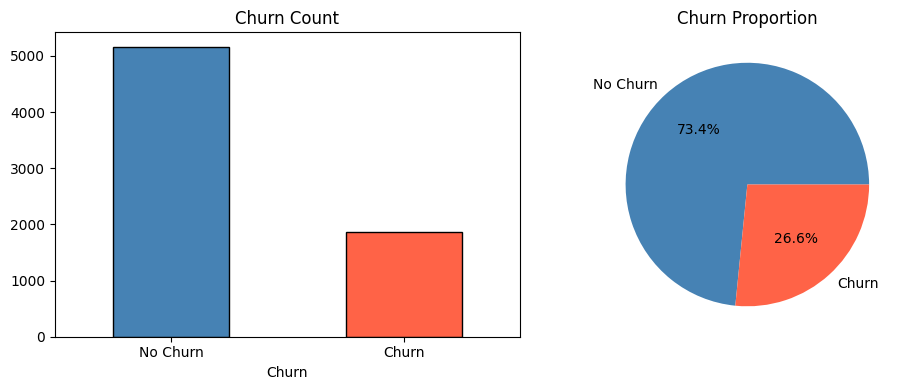

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df['Churn'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Pie chart
df['Churn'].value_counts().plot.pie(ax=axes[1], labels=['No Churn', 'Churn'],
                                     autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_ylabel('')
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

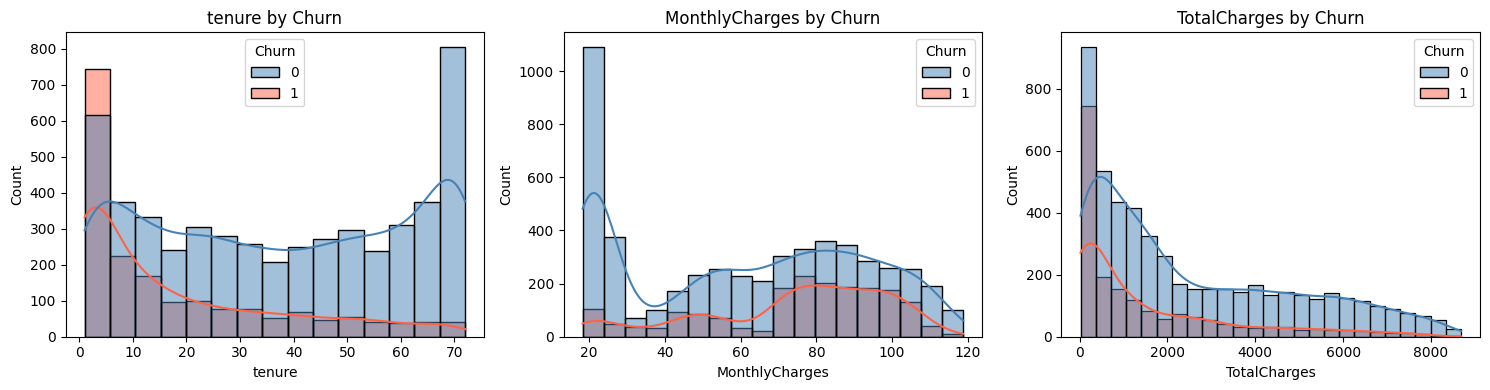

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax,
                 palette={0: 'steelblue', 1: 'tomato'})
    ax.set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()


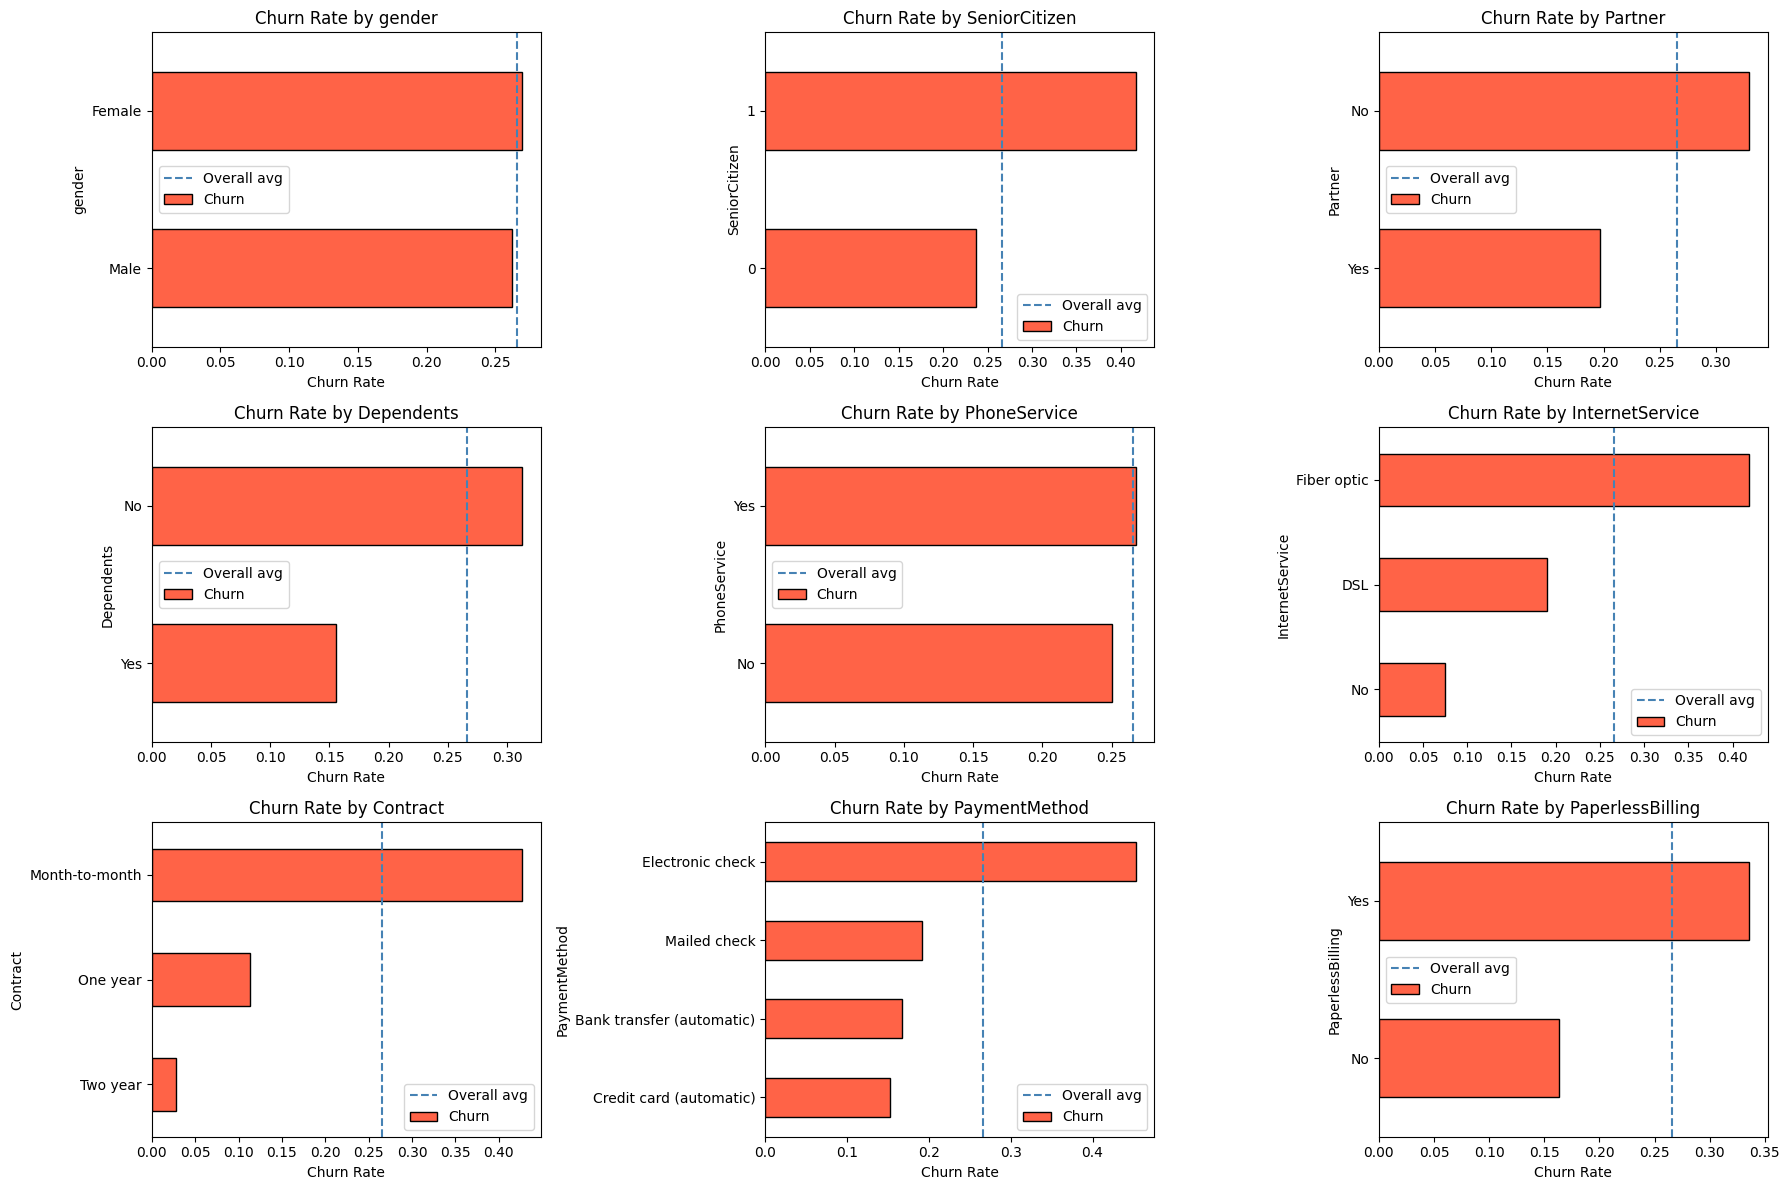

In [6]:


cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot.barh(ax=ax, color='tomato', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate')
    ax.axvline(df['Churn'].mean(), color='steelblue', linestyle='--', label='Overall avg')
    ax.legend()

plt.tight_layout()
plt.show()

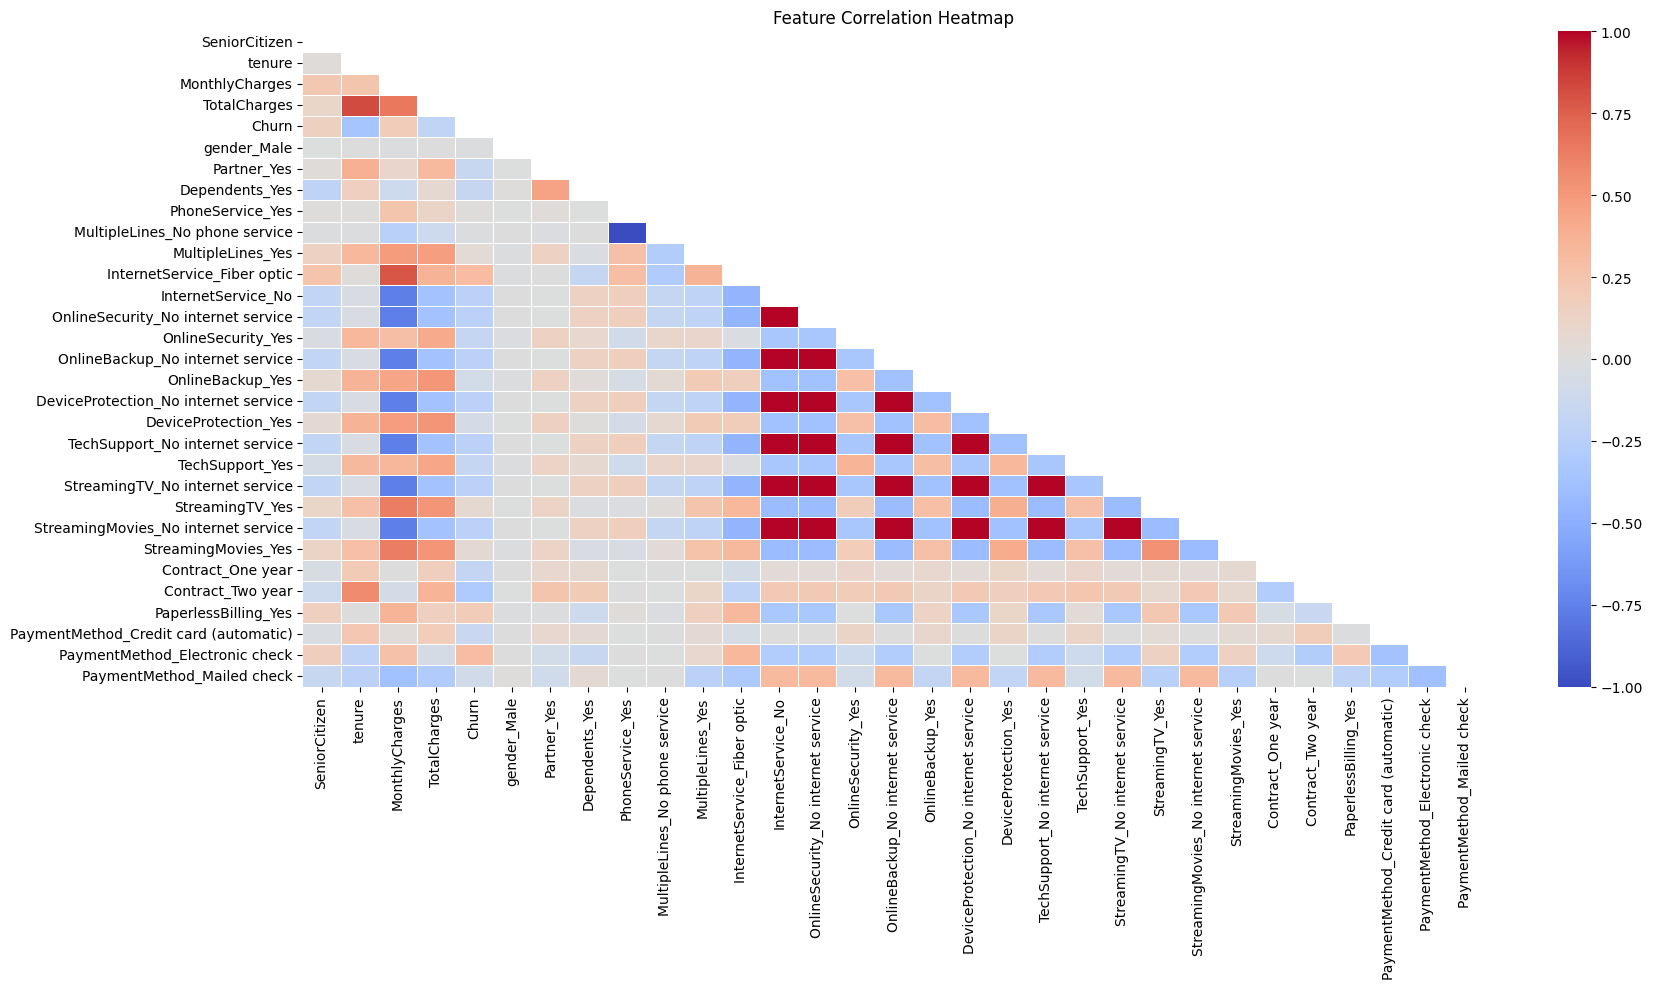


Top 10 features correlated with Churn:
tenure                                  0.354049
InternetService_Fiber optic             0.307463
Contract_Two year                       0.301552
PaymentMethod_Electronic check          0.301455
InternetService_No                      0.227578
OnlineSecurity_No internet service      0.227578
DeviceProtection_No internet service    0.227578
TechSupport_No internet service         0.227578
StreamingMovies_No internet service     0.227578
StreamingTV_No internet service         0.227578
Name: Churn, dtype: float64


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(18, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nTop 10 features correlated with Churn:")
print(corr['Churn'].abs().sort_values(ascending=False)[1:11])

In [8]:
df_encoded.to_csv('churn_cleaned.csv', index=False)
print("Saved! Ready for modeling.")
print(f"Final shape: {df_encoded.shape}")

Saved! Ready for modeling.
Final shape: (7032, 31)
